# prova structure 3

In [6]:
import tensorflow.keras.backend as K
from tensorflow.keras.regularizers import l2
from hyperopt import STATUS_OK, tpe, Trials, hp, fmin
from hyperopt.pyll.stochastic import sample
from hyperopt.pyll.base import scope
from sklearn.model_selection import KFold
import numpy as np
from matplotlib import pyplot as plt
from tensorflow.keras.optimizers import Adam,Nadam,Adamax
from time import perf_counter
import tensorflow as tf
import warnings
warnings.filterwarnings("ignore", category=DeprecationWarning, module="tensorflow")

import tinyDA as tda
from scipy.stats import multivariate_normal, uniform
import arviz as az
import keras
import sys



from module_utils import * 
from data_collection import *
sys.path.append('../utils')
from Structure3 import *
from pathlib import Path

# path to the current notebook
current_file_path = Path().resolve()
# path to the current folder
load_context_functions(current_file_path.parent.name)

# introduction of a seed for reproducibility purposes
seed = 10
tf.random.set_seed(seed)
np.random.seed(seed)
keras.utils.set_random_seed(seed)

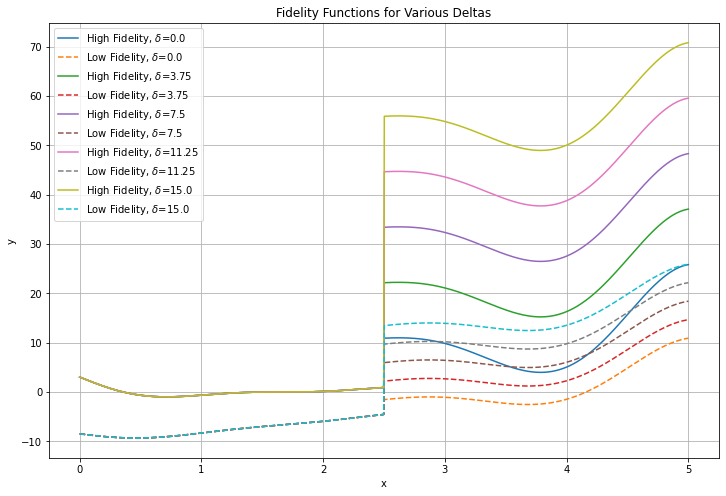

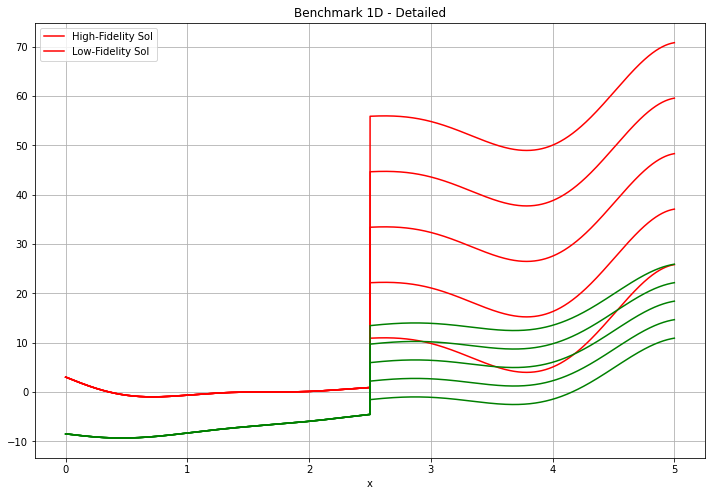

In [7]:
example = "Discontinuous"
fidelity_func = FidelityFunctionModified(example)
fidelity_func.plot_functions()
fidelity_func.plot_detailed_functions()

In [8]:
data=fidelity_func.get_parameters(example)

In [9]:
# parameters of the Neural Network
bestLF_params = {'lr' : 0.0255, 'kernel_init' : 'glorot_uniform', 'opt' : 'Adam'}
definition_LF={
        "network_type": "LF",
        "params": bestLF_params,
        "data_train": data["xlf"],
        "output_train": data["Ylf"],
        "N": data["NepoLF"],
        "n": data["Nlf"],
        "train": True,
        "do_HPO": False,
        "verbose": False
    }
# building of the neural network
modelLF=NetworkFactory.build_network(**definition_LF)
# prediction step
yLF=modelLF.prediction(data["datatest"])
(mse_LF,R2_LF)=modelLF.performance(data["datatest"],data["modified_highfid"](data["datatest"][:,0],data["datatest"][:,1]))

# Plot of the estimated results
plt.figure()
plt.plot(data["xlf"][:,0],data["Ylf"],'go', label = 'LF training data', markersize = 4)
plt.plot(data["datatest"][:,0],data["modified_lowfid"](data["datatest"][:,0],data["datatest"][:,1]),'g', label = 'exact LF') 
plt.plot(data["datatest"][:,0],yLF,'k--', label = 'pred LF')
plt.legend()
plt.title('Low fidelity model')

KeyboardInterrupt: 

The function training took 72.141995 seconds.


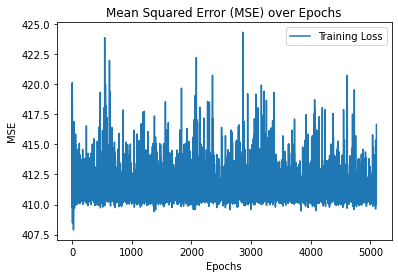

Test MSE: 391.80286709300026
R^2: 0.07458920538065117


Text(0.5, 1.0, 'High fidelity model')

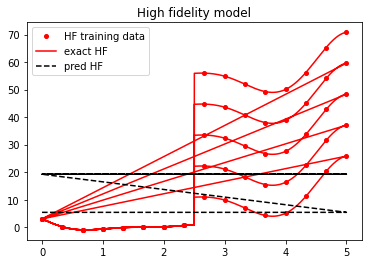

In [ ]:
# parameters of the Neural Network
bestHF_params = {'lr' : 0.0255, 'kernel_init' : 'glorot_uniform', 'opt' : 'Adam'}
definition_HF={
        "network_type": "LF",
        "params": bestLF_params,
        "data_train": data["xhf"],
        "output_train": data["Yhf"],
        "N": data["NepoHF"],
        "n": data["Nhf"],
        "train": True,
        "do_HPO": False,
        "verbose": False
    }
modelHF=NetworkFactory.build_network(**definition_HF)
yHF=modelHF.prediction(data["datatest"])
(mse_HF,R2_HF)=modelHF.performance(data["datatest"],data["modified_highfid"](data["datatest"][:,0],data["datatest"][:,1]))

# Plot of the estimated results
plt.figure()
plt.plot(data["xhf"][:,0],data["Yhf"],'ro', label = 'HF training data', markersize = 4)
plt.plot(data["datatest"][:,0],data["modified_highfid"](data["datatest"][:,0],data["datatest"][:,1]),'r', label = 'exact HF') 
plt.plot(data["datatest"][:,0],yHF,'k--', label = 'pred HF')
plt.legend()
plt.title('High fidelity model')



In [ ]:
### 2 steps NEURAL NETWORK ###
# collection of parameters
bestLF_params = {
    'lr': 0.0255, 
    'kernel_init': 'glorot_uniform', 
    'opt': 'Adam'
}

best_params = {
    'kernel_init': 'uniform', 
    'l2weight': 0.00010018625799978436, 
    'lr': 0.07093837044166487, 
    'nodes': 74.0, 
    'opt': 'Adamax'
}

params = [bestLF_params, best_params]

N = [data["NepoLF"], data["NepoHF"]]
n = [data["Nlf"], data["Nhf"]]

# names of the networks 
names = ['LF', 'HF']

# collection of the parameters
definition_2steps = {
    "network_type": "2step",
    "names": names,
    "params": params,
    "data_train": [data["xlf"], data["xhf"]],
    "output_train": [data["Ylf"], data["Yhf"]],
    "N": N,
    "n": n,
    "train": True,
    "do_HPO": True,
    "verbose": False
}

# creation of 2 steps model 
final_model = NetworkFactory.build_network(**definition_2steps)

if final_model == -1:
    raise ValueError("Failed to build the network. Check the network type and parameters.")

y_test=final_model.prediction(data["datatest"])

(mse_MF,R_MF)=final_model.performance(data["datatest"],data["modified_highfid"](data["datatest"][:,0],data["datatest"][:,1]))

    #(mse_MF,R_MF)=final_model.performance(data["x_test"].reshape(-1,1),data["high_fid"](data["x_test"]))

### PLOT of predicted models ###
#LF single-fidelity



plt.figure()
plt.plot(data["xhf"][:,0],data["Yhf"],'ro', label = 'HF training data', markersize = 4)
plt.plot(data["datatest"][:,0],data["modified_highfid"](data["datatest"][:,0],data["datatest"][:,1]),'r', label = 'exact HF') 
plt.plot(data["datatest"][:,0],y_test,'k--', label = 'pred HF')
plt.legend()
plt.title('High fidelity model')


[I 2024-08-02 10:45:03,902] A new study created in memory with name: no-name-edb77bd0-4118-41c8-8222-70708ea387af


1/1 [==============================] - 0s 293ms/step


# Prediction of a parameter 2 step nn

Sampling chain 1/2


Running chain, α = 0.60: 100%|██████████| 30/30 [00:02<00:00, 10.70it/s]


Sampling chain 2/2


Running chain, α = 0.60: 100%|██████████| 30/30 [00:02<00:00, 11.27it/s]
c:\Users\Giacomo\AppData\Local\Programs\Python\Python310\lib\site-packages\arviz\data\inference_data.py:146: UserWarning: qoi group is not defined in the InferenceData scheme
  warnings.warn(


Estimated values are [7.366]
     mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  ess_tail  \
x0  7.366  1.363   5.574    8.941      0.576    0.431       7.0      20.0   

    r_hat  
x0   1.69  
Autocorrelation...
The difference between estimated values [7.634]



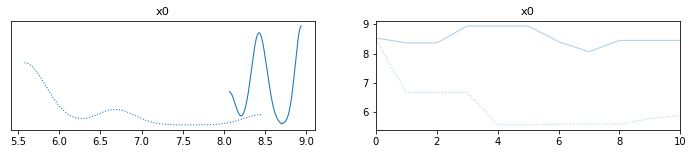

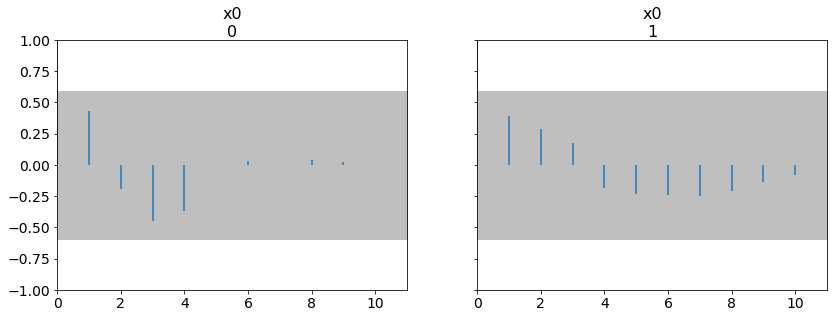

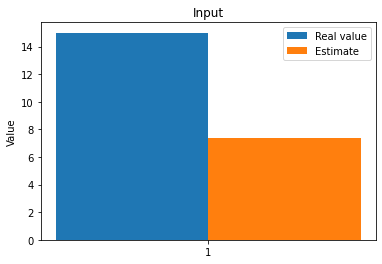

The function param_inverse took 7.435734 seconds.
Sampling chain 1/2


Running chain, α = 0.83: 100%|██████████| 30/30 [00:02<00:00, 10.61it/s]


Sampling chain 2/2


Running chain, α = 0.77: 100%|██████████| 30/30 [00:02<00:00, 11.86it/s]
c:\Users\Giacomo\AppData\Local\Programs\Python\Python310\lib\site-packages\arviz\data\inference_data.py:146: UserWarning: qoi group is not defined in the InferenceData scheme
  warnings.warn(


Estimated values are [7.422]
     mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  ess_tail  \
x0  7.422  0.377   6.834    7.909      0.117    0.086      10.0      15.0   

    r_hat  
x0    1.2  
Autocorrelation...
The difference between estimated values [7.578]



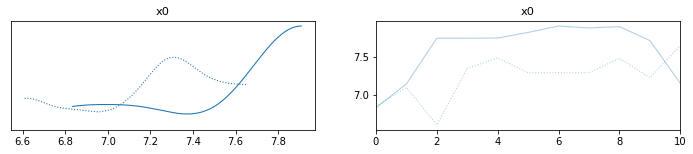

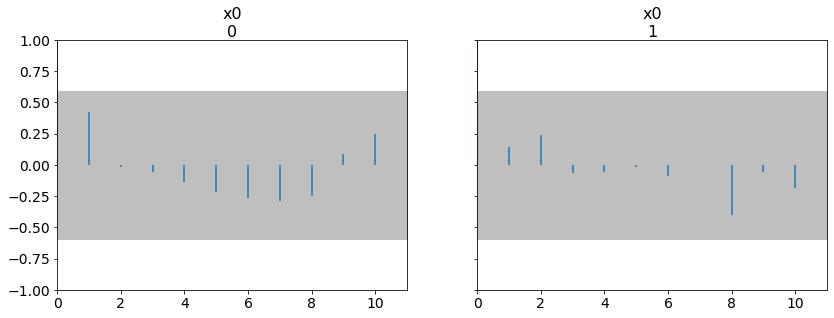

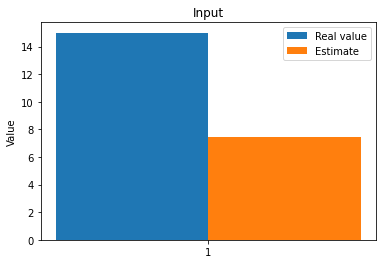

The function param_inverse took 6.978610 seconds.
Sampling chain 1/2


Running chain, α = 0.67: 100%|██████████| 30/30 [00:02<00:00, 10.98it/s]


Sampling chain 2/2


Running chain, α = 0.63: 100%|██████████| 30/30 [00:02<00:00, 11.34it/s]
c:\Users\Giacomo\AppData\Local\Programs\Python\Python310\lib\site-packages\arviz\data\inference_data.py:146: UserWarning: qoi group is not defined in the InferenceData scheme
  warnings.warn(


Estimated values are [6.314]
     mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  ess_tail  \
x0  6.314  0.808   5.565    7.395      0.288    0.212       8.0      10.0   

    r_hat  
x0   1.34  
Autocorrelation...
The difference between estimated values [8.686]



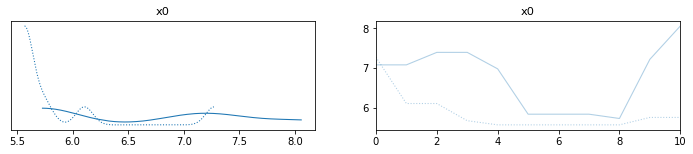

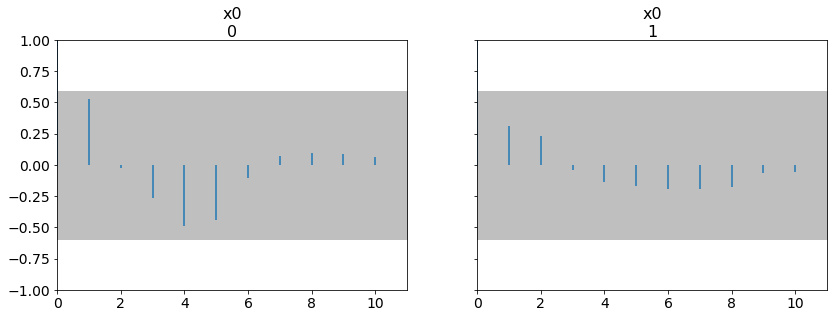

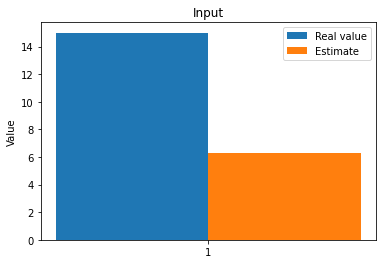

The function param_inverse took 6.945925 seconds.
Sampling chain 1/2


Running chain, α = 0.37: 100%|██████████| 30/30 [00:02<00:00, 10.48it/s]


Sampling chain 2/2


Running chain, α = 0.63: 100%|██████████| 30/30 [00:02<00:00, 12.30it/s]
c:\Users\Giacomo\AppData\Local\Programs\Python\Python310\lib\site-packages\arviz\data\inference_data.py:146: UserWarning: qoi group is not defined in the InferenceData scheme
  warnings.warn(


Estimated values are [6.641]
     mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  ess_tail  \
x0  6.641  0.539   5.715    7.435      0.169    0.126      11.0      14.0   

    r_hat  
x0   1.84  
Autocorrelation...
The difference between estimated values [8.359]



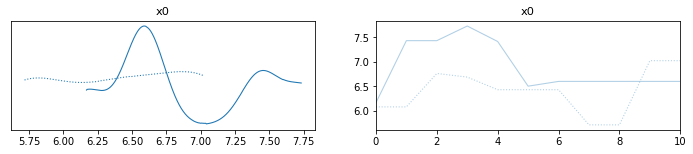

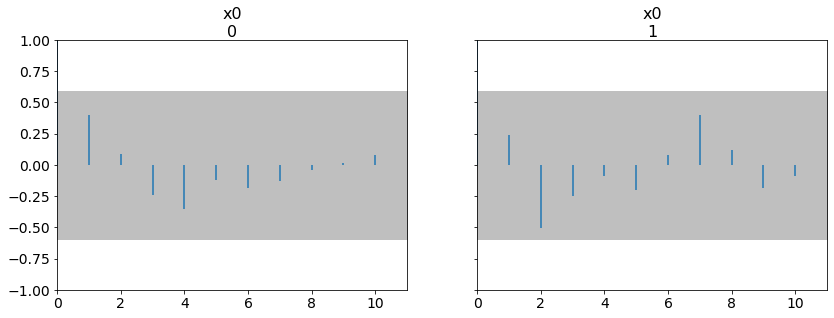

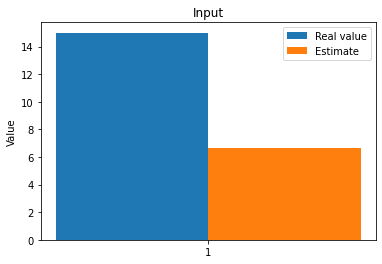

The function param_inverse took 7.425490 seconds.
Sampling chain 1/2


Running chain, α = 0.95:  67%|██████▋   | 20/30 [00:02<00:01,  9.83it/s]


KeyboardInterrupt: 

In [ ]:
mean_prior = np.array([7.])
cov_prior = np.diag([1.])

sigma_noise = [0.05,0.1]
n_data = [50,30]
parameters = np.array([15.])
sigma = np.array([ 4.,2.])
rwmh_scaling = np.array([ 2.,0.5,1.])
rwmh_cov = np.eye(1)
rwmh_adaptive = True
iterations = 30
burnin = 20
n_chains = 2
algo = "MH"


# ricorda che i primi due non vanno bene in qualunque caso
estimateLF, errorLF= run_simulation(data["xhf"], mean_prior, cov_prior, data["Yhf"], sigma_noise, n_data, parameters, sigma, rwmh_scaling, rwmh_cov, rwmh_adaptive, iterations, burnin, n_chains, modelLF,algo)
estimateHF, errorHF= run_simulation(data["xhf"], mean_prior, cov_prior, data["Yhf"], sigma_noise, n_data, parameters, sigma, rwmh_scaling, rwmh_cov, rwmh_adaptive, iterations, burnin, n_chains, modelHF,algo)

estimateMF, errorMF= run_simulation(data["xhf"], mean_prior, cov_prior, data["Yhf"], sigma_noise, n_data, parameters, sigma, rwmh_scaling, rwmh_cov, rwmh_adaptive, iterations, burnin, n_chains, final_model,algo)




In [ ]:

# Define inputs
mean_prior = np.array([7.])
cov_prior = np.diag([1.])
y_obs = data["Yhf"]
sd_noise = 0.1
N = 3000
burn_in = 2000
number_chains = 2
algo = "MH"
x_real = np.array([15.])
proposal_sd = 0.3
adapt = True
n_data = [30, 50]


x_data=  np.linspace(0., 5., n_data[0]).reshape(-1, 1)  # Generate evaluation times

nearest_x, y_obs = process_data(data["xhf"], parameters, x_data, Yhf) 

estimates = final_model.inverse_cuqi(
    mean_prior=mean_prior,
    x_real=x_real,
    y_obs=y_obs,
    N=N,
    burn_in=burn_in,
    cov_prior=cov_prior,
    sd_noise=sd_noise,  
    adapt=adapt,
    scale=proposal_sd,
    proposal_sd=proposal_sd,
    number_chains=number_chains,
    algo=algo,
    x_data=x_data
)

NameError: name 'parameters' is not defined

In [ ]:
data["Yhf"].shape

(80,)

In [ ]:
mean_prior = np.array([7.])
cov_prior = np.diag([1.])
Yhf = np.array([10, 20, 30, 40, 50])
sigma_noise = [0.1, 0.05]
n_data = [30, 50]
parameters = np.array([15.])
sigma = np.array([2., 4.])
rwmh_scaling = np.array([0.5, 1., 2.])
rwmh_cov = np.eye(1)
rwmh_adaptive = True
iterations = 3000
burnin = 2000
n_chains = 2
algo = "MH"

In [ ]:
# Define inputs
mean_prior = np.array([7.])
cov_prior = np.diag([1.])
Yhf = data["Yhf"]
sd_noise = [0.1,0.05]
N = 30
burn_in = 20
number_chains = 2
algo = "MH"
x_real = np.array([15.])
proposal_sd = [4.,2.]
adapt = True
n_data = [50,30]



module_directory = os.path.abspath(os.path.join('..', 'utils'))

# Add the 'utils' directory containing Structure2.py to the PYTHONPATH
os.environ['PYTHONPATH'] = module_directory
sys.path.append(module_directory)


x_data=  np.linspace(0., 5., n_data[0]).reshape(-1, 1)  # Generate evaluation times
nearest_x, y_obs = process_data(data["xhf"], x_real, x_data, Yhf) 

# estimates = final_model.inverse_cuqi(
#     mean_prior=mean_prior,
#     x_real=x_real,
#     y_obs=y_obs,
#     N=N,
#     burn_in=burn_in,
#     cov_prior=cov_prior,
#     sd_noise=sd_noise,  
#     adapt=adapt,
#     scale=proposal_sd,
#     proposal_sd=proposal_sd,
#     number_chains=number_chains,
#     algo=algo,
#     x_data=x_data
# )

best_estimate,best_error=run_simulation_cuqi(data,
    mean_prior,
    x_real,
    N,
    burn_in,
    cov_prior,
    sd_noise,  
    adapt,
    
    proposal_sd,
    number_chains,
    algo,
    x_data,
    n_data,
    modelLF,
    parallel=True
) 



Keras weights file (<HDF5 file "variables.h5" (mode r+)>) saving:
...layers\dense
......vars
.........0
.........1
...layers\dense_1
......vars
.........0
.........1
...layers\dense_2
......vars
.........0
.........1
...layers\dense_3
......vars
.........0
.........1
...layers\dense_4
......vars
.........0
.........1
...layers\input_layer
......vars
...metrics\mean
......vars
.........0
.........1
...metrics\mean_metric_wrapper
......vars
.........0
.........1
...optimizer
......vars
.........0
.........1
.........10
.........11
.........12
.........13
.........14
.........15
.........16
.........17
.........18
.........19
.........2
.........20
.........21
.........22
.........23
.........24
.........25
.........26
.........27
.........28
.........29
.........3
.........30
.........4
.........5
.........6
.........7
.........8
.........9
...vars
Keras model archive saving:
File Name                                             Modified             Size
config.json                      

KeyboardInterrupt: 

Sample 30 / 30

Average acceptance rate: 0.7 MCMC scale: 1 

Mean values: [9.46697594]
The function chain_creation took 8.107001304626465 seconds.
Sample 30 / 30

Average acceptance rate: 0.4 MCMC scale: 1 

Mean values: [6.91791986]
The function chain_creation took 5.119001388549805 seconds.


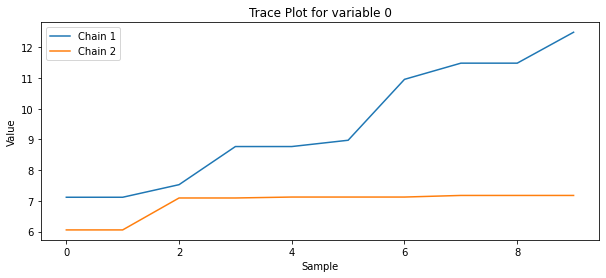

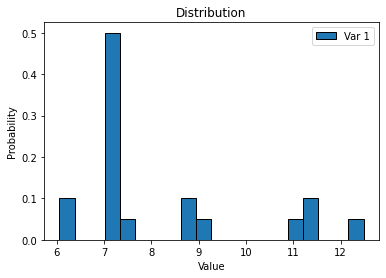

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


ESS values = 5.767741395488823


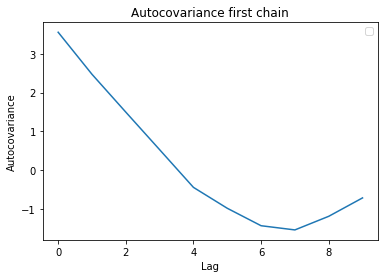

Error wrt true parameters: 6.8075521003662764
The difference between estimated values [6.8075521]



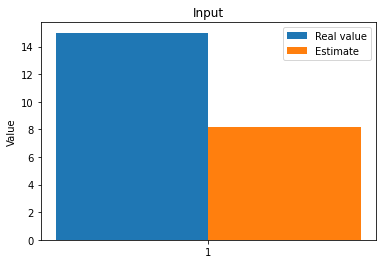

The function inverse_cuqi took 14.455999 seconds.
Sample 30 / 30

Average acceptance rate: 0.6 MCMC scale: 1 

Mean values: [13.09132152]
The function chain_creation took 6.135878801345825 seconds.
Sample 30 / 30

Average acceptance rate: 0.5 MCMC scale: 1 

Mean values: [8.80734119]
The function chain_creation took 5.1187872886657715 seconds.


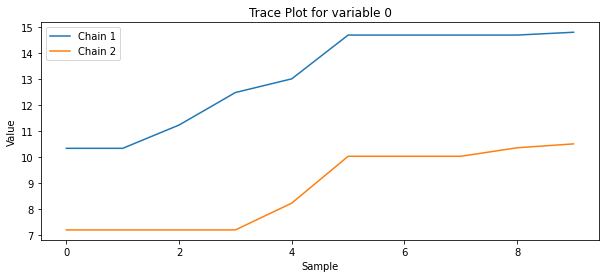

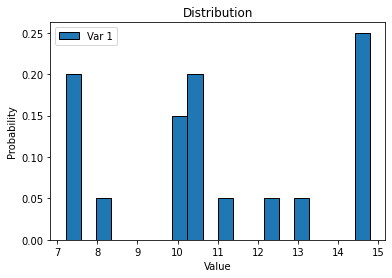

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


ESS values = 5.374828629043542


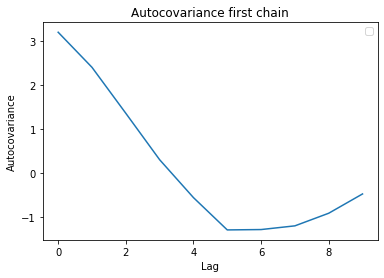

Error wrt true parameters: 4.050668646238297
The difference between estimated values [4.05066865]



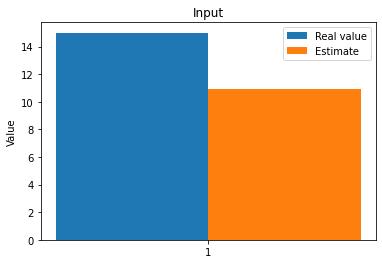

The function inverse_cuqi took 12.205624 seconds.
Sample 30 / 30

Average acceptance rate: 0.5 MCMC scale: 1 

Mean values: [7.32862381]
The function chain_creation took 5.215944290161133 seconds.
Sample 13 / 30

KeyboardInterrupt: 

In [ ]:
# Define inputs
mean_prior = np.array([7.])
cov_prior = np.diag([1.])
Yhf = data["Yhf"]
sd_noise = [0.1,0.05]
N = 30
burn_in = 20
number_chains = 2
algo = "MH"
x_real = np.array([15.])
proposal_sd = [4.,2.]
adapt = True
n_data = [50,30]


module_directory = os.path.abspath(os.path.join('..', 'utils'))

# Add the 'utils' directory containing Structure2.py to the PYTHONPATH
os.environ['PYTHONPATH'] = module_directory
sys.path.append(module_directory)


x_data=  np.linspace(0., 5., n_data[0]).reshape(-1, 1)  # Generate evaluation times
nearest_x, y_obs = process_data(data["xhf"], x_real, x_data, Yhf) 

# estimates = final_model.inverse_cuqi(
#     mean_prior=mean_prior,
#     x_real=x_real,
#     y_obs=y_obs,
#     N=N,
#     burn_in=burn_in,
#     cov_prior=cov_prior,
#     sd_noise=sd_noise,  
#     adapt=adapt,
#     scale=proposal_sd,
#     proposal_sd=proposal_sd,
#     number_chains=number_chains,
#     algo=algo,
#     x_data=x_data
# )

best_estimate,best_error=run_simulation_cuqi(data,
    mean_prior,
    x_real,
    N,
    burn_in,
    cov_prior,
    sd_noise,  
    adapt,
    
    proposal_sd,
    number_chains,
    algo,
    x_data,
    n_data,
    final_model,
    parallel=False
) 




Keras weights file (<HDF5 file "variables.h5" (mode r+)>) saving:
...layers\dense
......vars
.........0
.........1
...layers\dense_1
......vars
.........0
.........1
...layers\dense_2
......vars
.........0
.........1
...layers\dense_3
......vars
.........0
.........1
...layers\dense_4
......vars
.........0
.........1
...layers\input_layer
......vars
...metrics\mean
......vars
.........0
.........1
...metrics\mean_metric_wrapper
......vars
.........0
.........1
...optimizer
......vars
.........0
.........1
.........10
.........11
.........12
.........13
.........14
.........15
.........16
.........17
.........18
.........19
.........2
.........20
.........21
.........22
.........23
.........24
.........25
.........26
.........27
.........28
.........29
.........3
.........30
.........4
.........5
.........6
.........7
.........8
.........9
...vars
Keras model archive saving:
File Name                                             Modified             Size
config.json                     

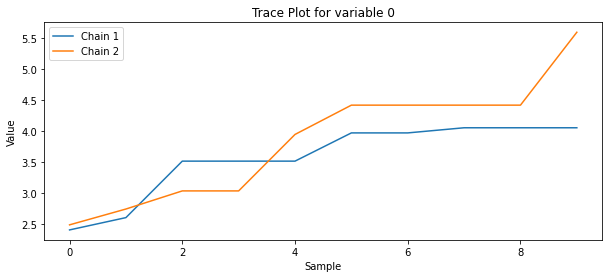

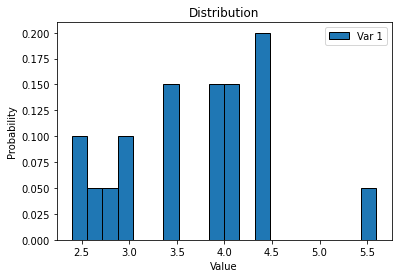

c:\Users\Giacomo\AppData\Local\Programs\Python\Python310\lib\site-packages\arviz\utils.py:187: NumbaDeprecationWarning: The 'nopython' keyword argument was not supplied to the 'numba.jit' decorator. The implicit default value for this argument is currently False, but it will be changed to True in Numba 0.59.0. See https://numba.readthedocs.io/en/stable/reference/deprecation.html#deprecation-of-object-mode-fall-back-behaviour-when-using-jit for details.
  numba_fn = numba.jit(**self.kwargs)(self.function)
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


ESS values = 5.841536931592086


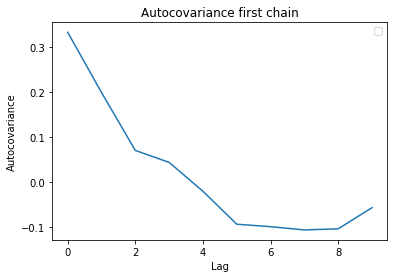

Error wrt true parameters: 11.293505947300309
The difference between estimated values [11.29350595]



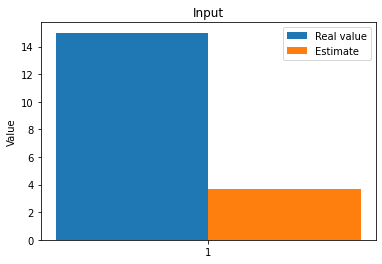

The function inverse_cuqi took 34.186663 seconds.

Keras weights file (<HDF5 file "variables.h5" (mode r+)>) saving:
...layers\dense
......vars
.........0
.........1
...layers\dense_1
......vars
.........0
.........1
...layers\dense_2
......vars
.........0
.........1
...layers\dense_3
......vars
.........0
.........1
...layers\dense_4
......vars
.........0
.........1
...layers\input_layer
......vars
...metrics\mean
......vars
.........0
.........1
...metrics\mean_metric_wrapper
......vars
.........0
.........1
...optimizer
......vars
.........0
.........1
.........10
.........11
.........12
.........13
.........14
.........15
.........16
.........17
.........18
.........19
.........2
.........20
.........21
.........22
.........23
.........24
.........25
.........26
.........27
.........28
.........29
.........3
.........30
.........4
.........5
.........6
.........7
.........8
.........9
...vars
Keras model archive saving:
File Name                                             Modified

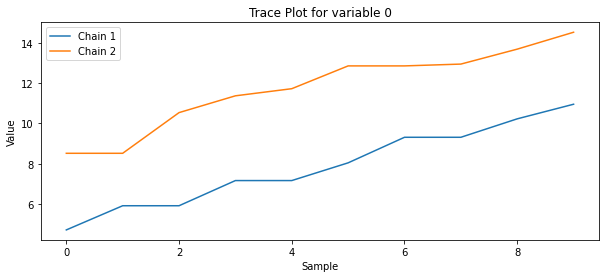

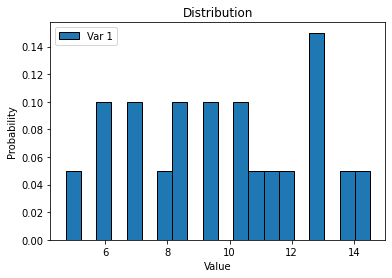

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


ESS values = 5.54637104510147


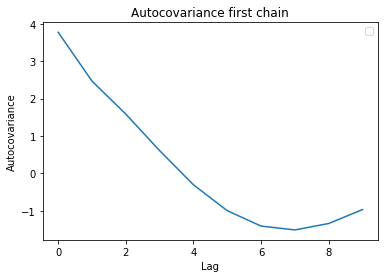

Error wrt true parameters: 5.184128999393209
The difference between estimated values [5.184129]



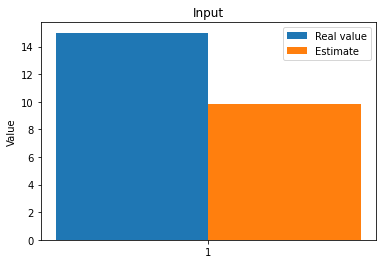

The function inverse_cuqi took 32.140169 seconds.

Keras weights file (<HDF5 file "variables.h5" (mode r+)>) saving:
...layers\dense
......vars
.........0
.........1
...layers\dense_1
......vars
.........0
.........1
...layers\dense_2
......vars
.........0
.........1
...layers\dense_3
......vars
.........0
.........1
...layers\dense_4
......vars
.........0
.........1
...layers\input_layer
......vars
...metrics\mean
......vars
.........0
.........1
...metrics\mean_metric_wrapper
......vars
.........0
.........1
...optimizer
......vars
.........0
.........1
.........10
.........11
.........12
.........13
.........14
.........15
.........16
.........17
.........18
.........19
.........2
.........20
.........21
.........22
.........23
.........24
.........25
.........26
.........27
.........28
.........29
.........3
.........30
.........4
.........5
.........6
.........7
.........8
.........9
...vars
Keras model archive saving:
File Name                                             Modified

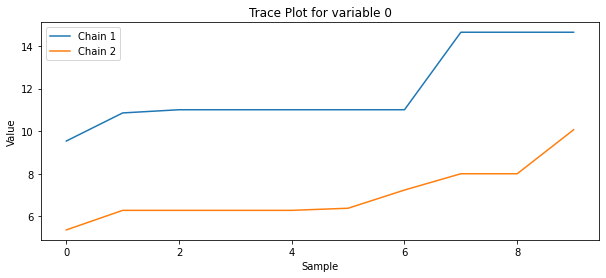

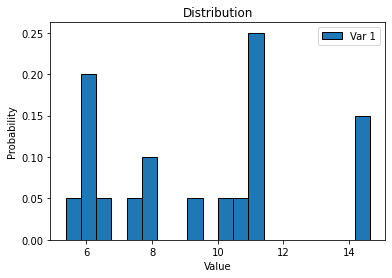

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


ESS values = 5.453868585396957


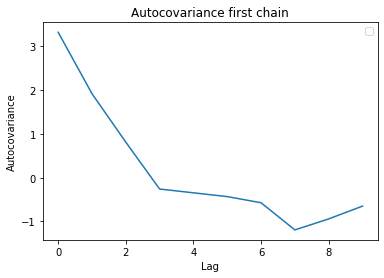

Error wrt true parameters: 5.5221667252106315
The difference between estimated values [5.52216673]



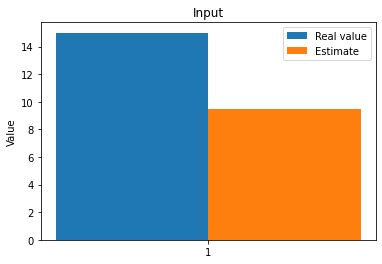

The function inverse_cuqi took 31.298657 seconds.

Keras weights file (<HDF5 file "variables.h5" (mode r+)>) saving:
...layers\dense
......vars
.........0
.........1
...layers\dense_1
......vars
.........0
.........1
...layers\dense_2
......vars
.........0
.........1
...layers\dense_3
......vars
.........0
.........1
...layers\dense_4
......vars
.........0
.........1
...layers\input_layer
......vars
...metrics\mean
......vars
.........0
.........1
...metrics\mean_metric_wrapper
......vars
.........0
.........1
...optimizer
......vars
.........0
.........1
.........10
.........11
.........12
.........13
.........14
.........15
.........16
.........17
.........18
.........19
.........2
.........20
.........21
.........22
.........23
.........24
.........25
.........26
.........27
.........28
.........29
.........3
.........30
.........4
.........5
.........6
.........7
.........8
.........9
...vars
Keras model archive saving:
File Name                                             Modified

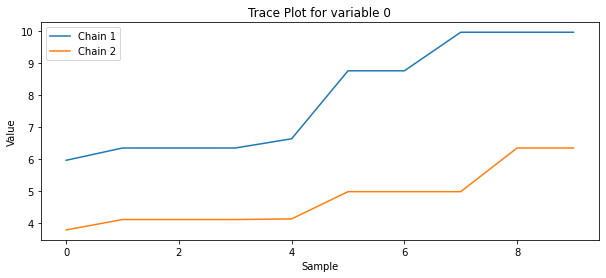

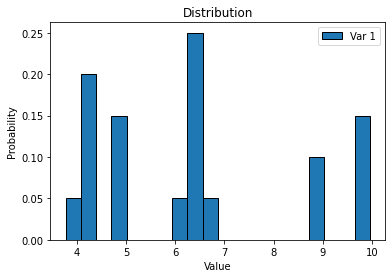

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


ESS values = 5.504975462690677


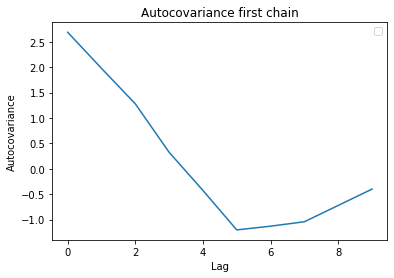

Error wrt true parameters: 8.66225140236596
The difference between estimated values [8.6622514]



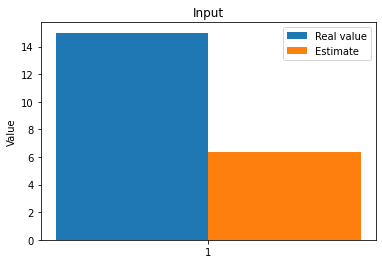

The function inverse_cuqi took 30.776066 seconds.

Keras weights file (<HDF5 file "variables.h5" (mode r+)>) saving:
...layers\dense
......vars
.........0
.........1
...layers\dense_1
......vars
.........0
.........1
...layers\dense_2
......vars
.........0
.........1
...layers\dense_3
......vars
.........0
.........1
...layers\dense_4
......vars
.........0
.........1
...layers\input_layer
......vars
...metrics\mean
......vars
.........0
.........1
...metrics\mean_metric_wrapper
......vars
.........0
.........1
...optimizer
......vars
.........0
.........1
.........10
.........11
.........12
.........13
.........14
.........15
.........16
.........17
.........18
.........19
.........2
.........20
.........21
.........22
.........23
.........24
.........25
.........26
.........27
.........28
.........29
.........3
.........30
.........4
.........5
.........6
.........7
.........8
.........9
...vars
Keras model archive saving:
File Name                                             Modified

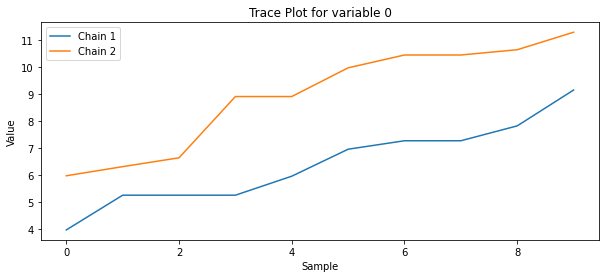

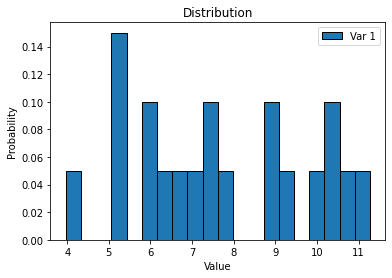

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


ESS values = 5.556507938669503


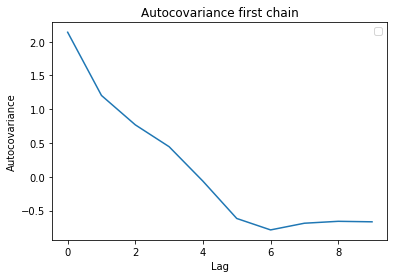

Error wrt true parameters: 7.32513551485845
The difference between estimated values [7.32513551]



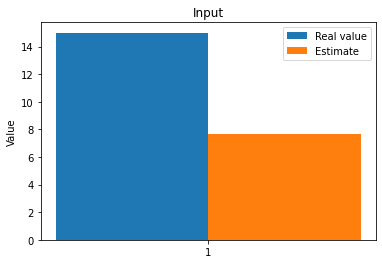

The function inverse_cuqi took 31.229533 seconds.

Keras weights file (<HDF5 file "variables.h5" (mode r+)>) saving:
...layers\dense
......vars
.........0
.........1
...layers\dense_1
......vars
.........0
.........1
...layers\dense_2
......vars
.........0
.........1
...layers\dense_3
......vars
.........0
.........1
...layers\dense_4
......vars
.........0
.........1
...layers\input_layer
......vars
...metrics\mean
......vars
.........0
.........1
...metrics\mean_metric_wrapper
......vars
.........0
.........1
...optimizer
......vars
.........0
.........1
.........10
.........11
.........12
.........13
.........14
.........15
.........16
.........17
.........18
.........19
.........2
.........20
.........21
.........22
.........23
.........24
.........25
.........26
.........27
.........28
.........29
.........3
.........30
.........4
.........5
.........6
.........7
.........8
.........9
...vars
Keras model archive saving:
File Name                                             Modified

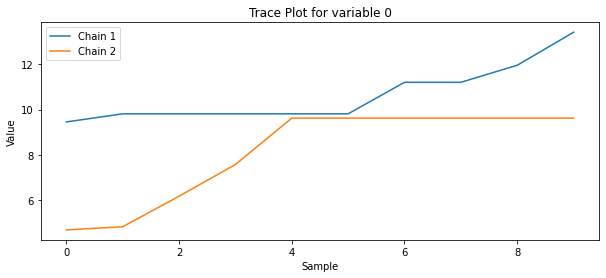

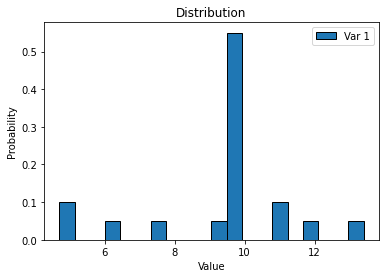

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


ESS values = 5.8772171724243245


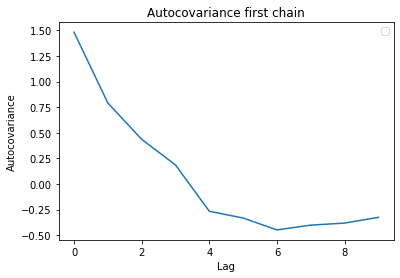

Error wrt true parameters: 5.632852837125576
The difference between estimated values [5.63285284]



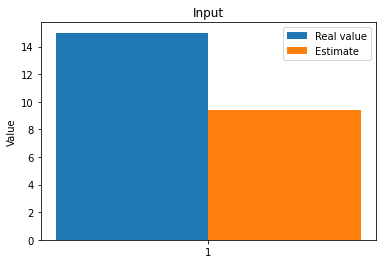

The function inverse_cuqi took 32.136897 seconds.

Keras weights file (<HDF5 file "variables.h5" (mode r+)>) saving:
...layers\dense
......vars
.........0
.........1
...layers\dense_1
......vars
.........0
.........1
...layers\dense_2
......vars
.........0
.........1
...layers\dense_3
......vars
.........0
.........1
...layers\dense_4
......vars
.........0
.........1
...layers\input_layer
......vars
...metrics\mean
......vars
.........0
.........1
...metrics\mean_metric_wrapper
......vars
.........0
.........1
...optimizer
......vars
.........0
.........1
.........10
.........11
.........12
.........13
.........14
.........15
.........16
.........17
.........18
.........19
.........2
.........20
.........21
.........22
.........23
.........24
.........25
.........26
.........27
.........28
.........29
.........3
.........30
.........4
.........5
.........6
.........7
.........8
.........9
...vars
Keras model archive saving:
File Name                                             Modified

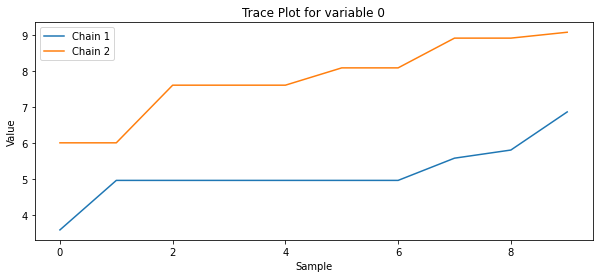

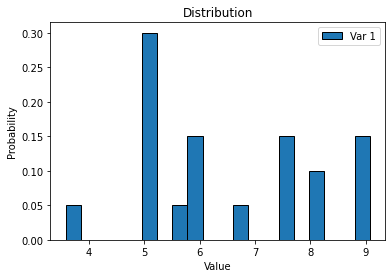

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


ESS values = 5.599617673795646


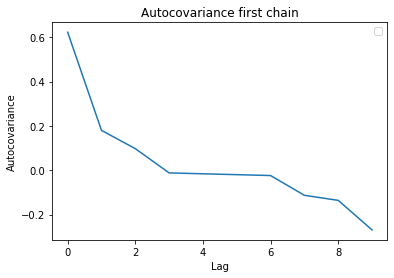

Error wrt true parameters: 8.528526917606285
The difference between estimated values [8.52852692]



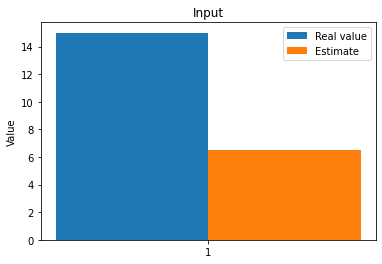

The function inverse_cuqi took 30.780438 seconds.

Keras weights file (<HDF5 file "variables.h5" (mode r+)>) saving:
...layers\dense
......vars
.........0
.........1
...layers\dense_1
......vars
.........0
.........1
...layers\dense_2
......vars
.........0
.........1
...layers\dense_3
......vars
.........0
.........1
...layers\dense_4
......vars
.........0
.........1
...layers\input_layer
......vars
...metrics\mean
......vars
.........0
.........1
...metrics\mean_metric_wrapper
......vars
.........0
.........1
...optimizer
......vars
.........0
.........1
.........10
.........11
.........12
.........13
.........14
.........15
.........16
.........17
.........18
.........19
.........2
.........20
.........21
.........22
.........23
.........24
.........25
.........26
.........27
.........28
.........29
.........3
.........30
.........4
.........5
.........6
.........7
.........8
.........9
...vars
Keras model archive saving:
File Name                                             Modified

KeyboardInterrupt: 

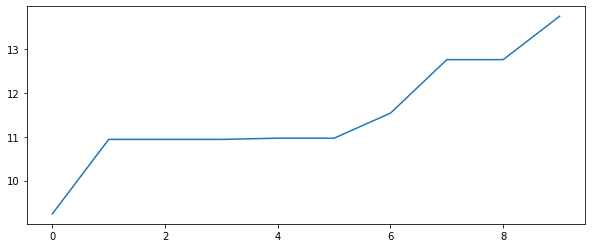

In [ ]:
# Define inputs
mean_prior = np.array([7.])
cov_prior = np.diag([1.])
Yhf = data["Yhf"]
sd_noise = [0.1,0.05]
N = 30
burn_in = 20
number_chains = 2
algo = "MH"
x_real = np.array([15.])
proposal_sd = [4.,2.]
adapt = True
n_data = [50,30]


module_directory = os.path.abspath(os.path.join('..', 'utils'))

# Add the 'utils' directory containing Structure2.py to the PYTHONPATH
os.environ['PYTHONPATH'] = module_directory
sys.path.append(module_directory)


x_data=  np.linspace(0., 5., n_data[0]).reshape(-1, 1)  # Generate evaluation times
nearest_x, y_obs = process_data(data["xhf"], x_real, x_data, Yhf) 

# estimates = final_model.inverse_cuqi(
#     mean_prior=mean_prior,
#     x_real=x_real,
#     y_obs=y_obs,
#     N=N,
#     burn_in=burn_in,
#     cov_prior=cov_prior,
#     sd_noise=sd_noise,  
#     adapt=adapt,
#     scale=proposal_sd,
#     proposal_sd=proposal_sd,
#     number_chains=number_chains,
#     algo=algo,
#     x_data=x_data
# )

best_estimate,best_error=run_simulation_cuqi(data,
    mean_prior,
    x_real,
    N,
    burn_in,
    cov_prior,
    sd_noise,  
    adapt,
    
    proposal_sd,
    number_chains,
    algo,
    x_data,
    n_data,
    final_model,
    parallel=True
) 



In [ ]:
        ray.shutdown()


Sample 3000 / 3000

Average acceptance rate: 0.31 MCMC scale: 0.6249622686431184 

Mean values = [14.8533291]
Sample 2970 / 3000

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


Sample 3000 / 3000

Average acceptance rate: 0.299 MCMC scale: 0.6130123585872429 

Mean values = [14.85638325]
(2, 1, 1000)


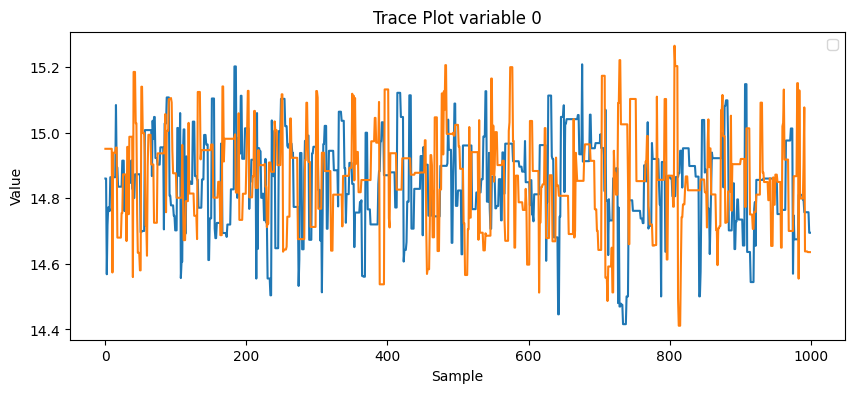

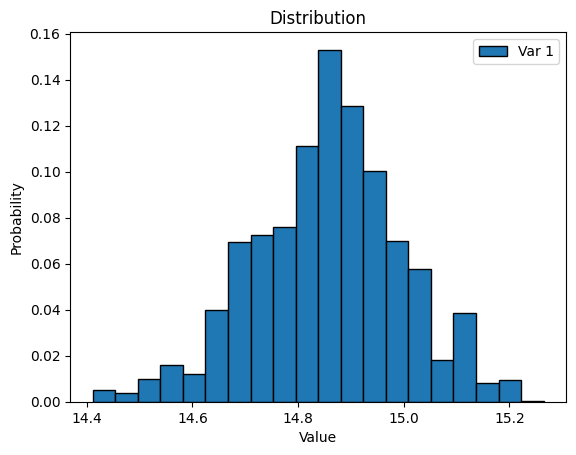

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


ESS values = 378.5746147278357


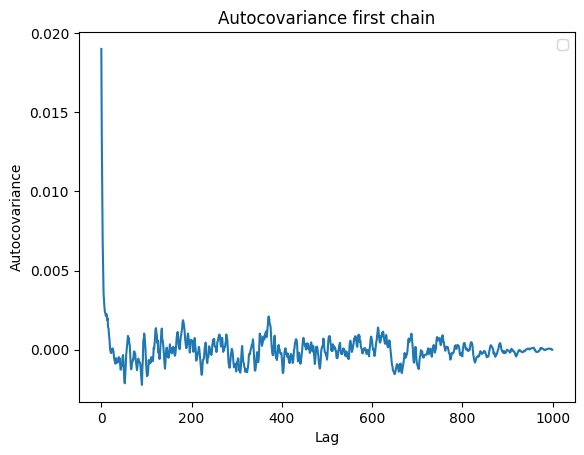

the difference between estimated values [0.14361675]



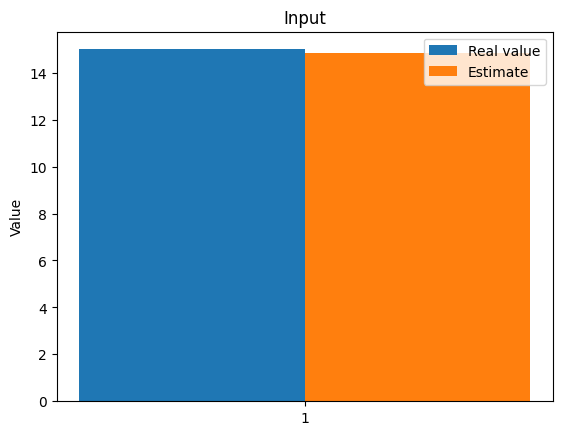

Sample 3000 / 3000

Average acceptance rate: 0.26 MCMC scale: 0.4367660225755193 

Mean values = [14.9228205]
Sample 2970 / 3000

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


Sample 3000 / 3000

Average acceptance rate: 0.268 MCMC scale: 0.4541695530693019 

Mean values = [14.91729729]
(2, 1, 1000)


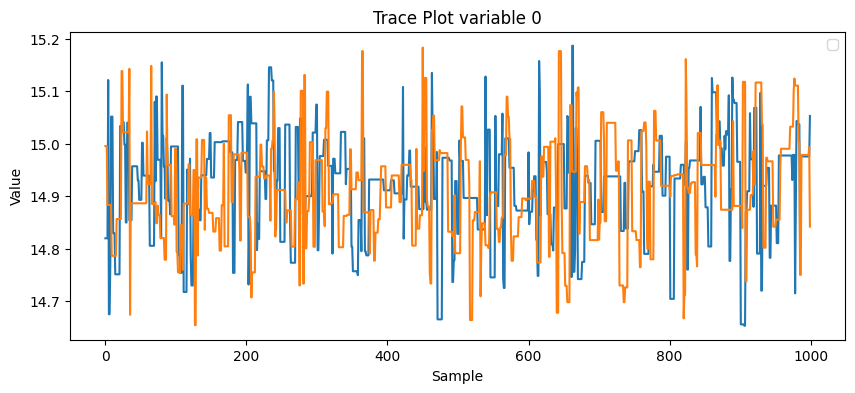

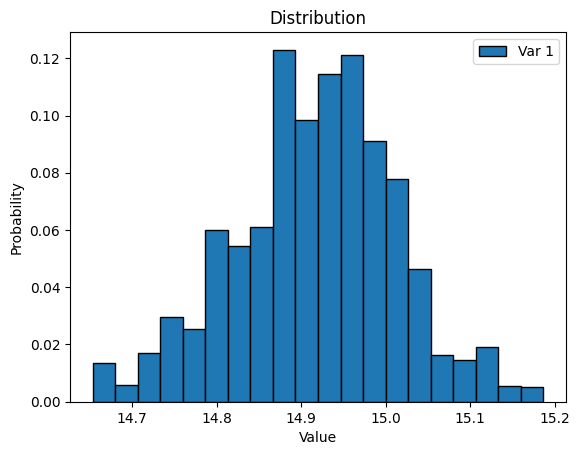

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


ESS values = 423.0425194756


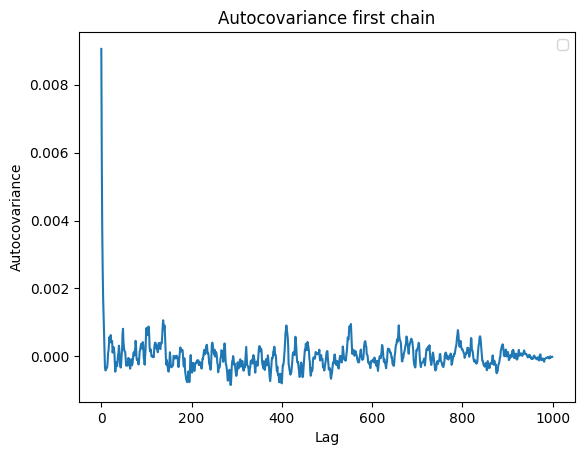

the difference between estimated values [0.08270271]



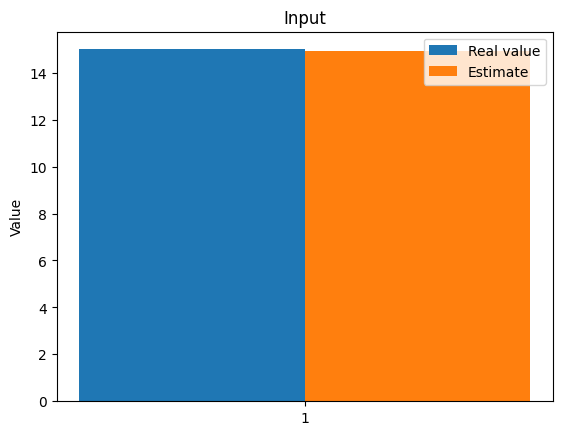

Sample 3000 / 3000

Average acceptance rate: 0.305 MCMC scale: 0.7763530803778186 

Mean values = [14.7505142]
Sample 2970 / 3000

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


Sample 3000 / 3000

Average acceptance rate: 0.277 MCMC scale: 0.7344583613957313 

Mean values = [14.75779272]
(2, 1, 1000)


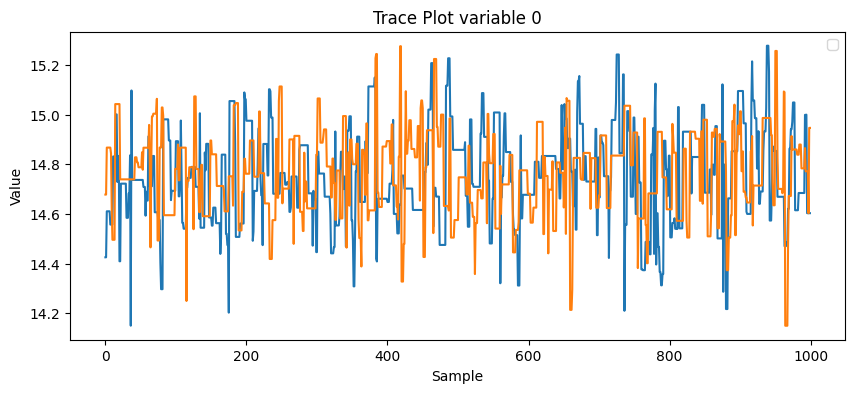

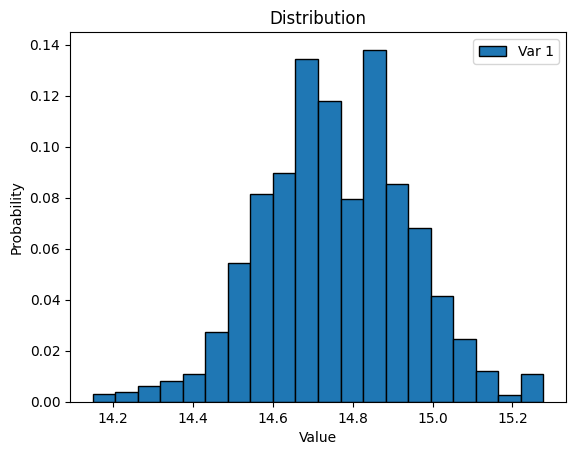

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


ESS values = 443.0052654580456


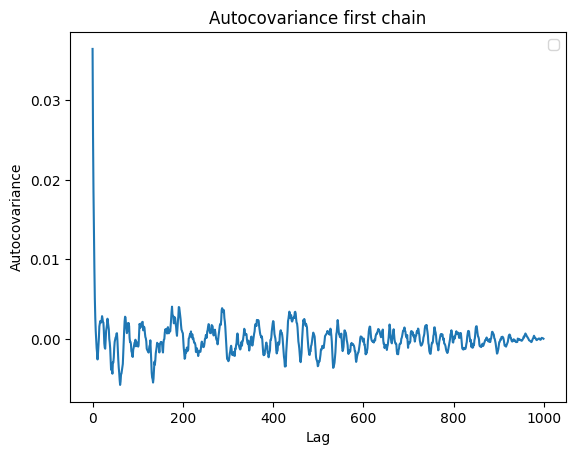

the difference between estimated values [0.24220728]



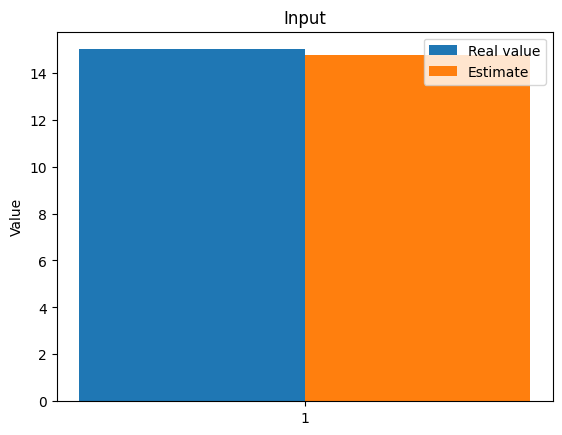

Sample 3000 / 3000

Average acceptance rate: 0.287 MCMC scale: 0.5578642808297212 

Mean values = [14.8650416]
Sample 2970 / 3000

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


Sample 3000 / 3000

Average acceptance rate: 0.275 MCMC scale: 0.5949934253988892 

Mean values = [14.87005089]
(2, 1, 1000)


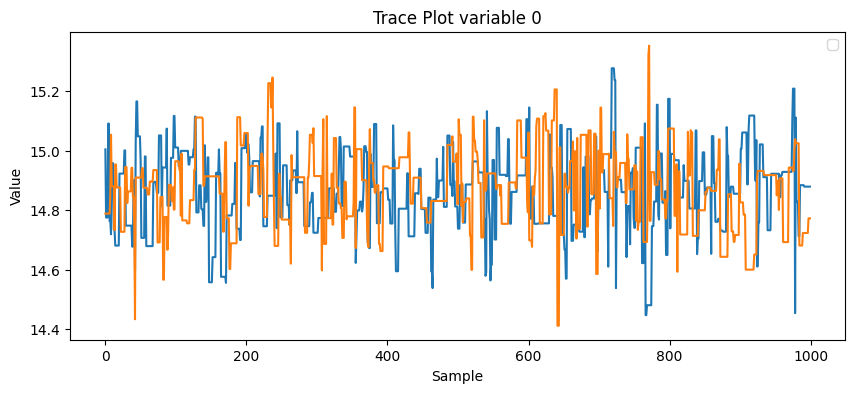

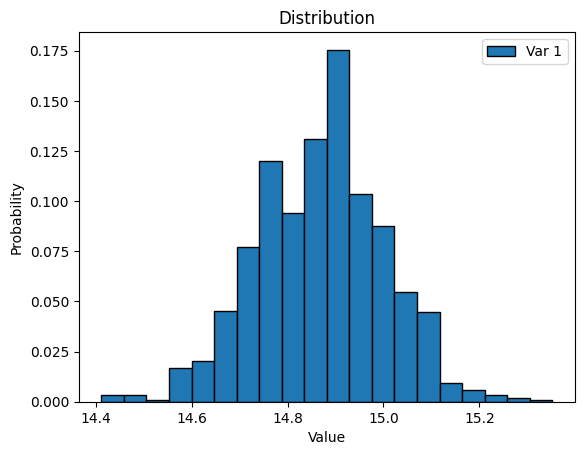

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


ESS values = 324.77619974295993


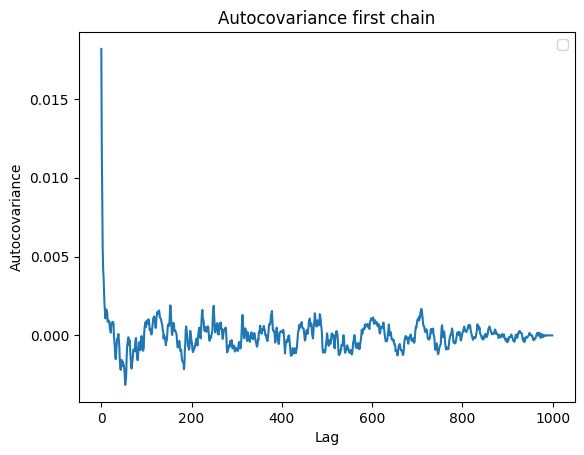

the difference between estimated values [0.12994911]



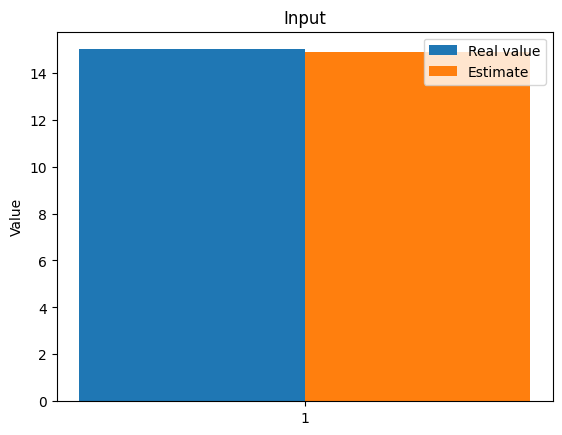

Sample 3000 / 3000

Average acceptance rate: 0.287 MCMC scale: 0.6360076776492017 

Mean values = [14.849556]
Sample 2970 / 3000

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


Sample 3000 / 3000

Average acceptance rate: 0.308 MCMC scale: 0.6422882836555098 

Mean values = [14.84425001]
(2, 1, 1000)


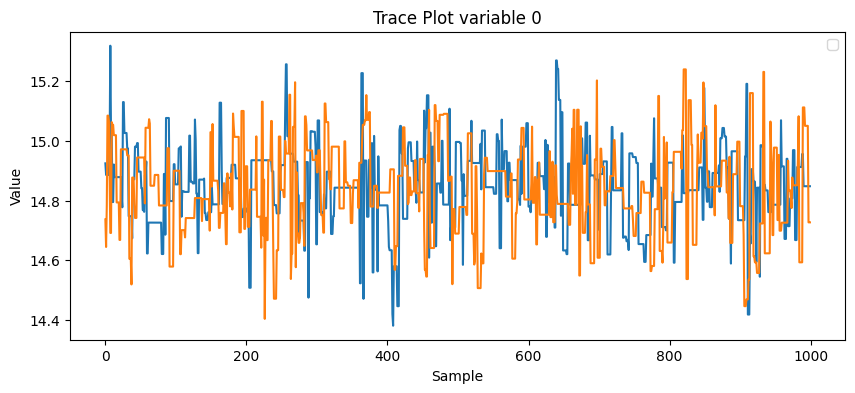

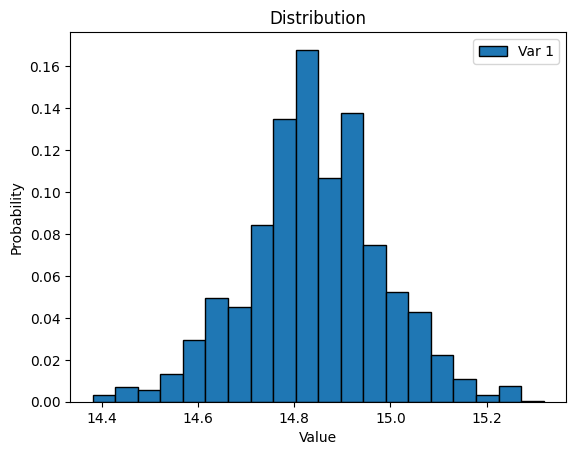

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


ESS values = 418.0888171575336


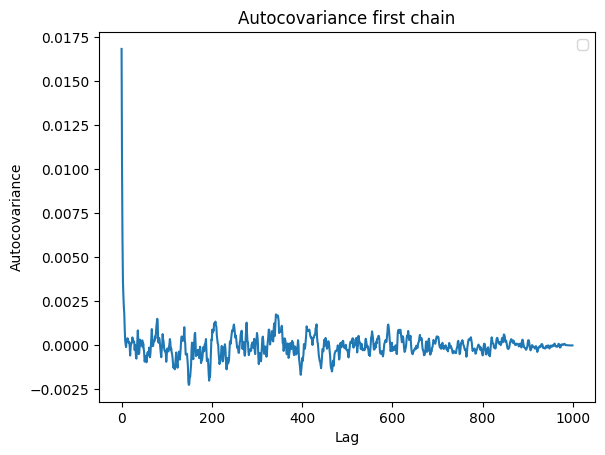

the difference between estimated values [0.15574999]



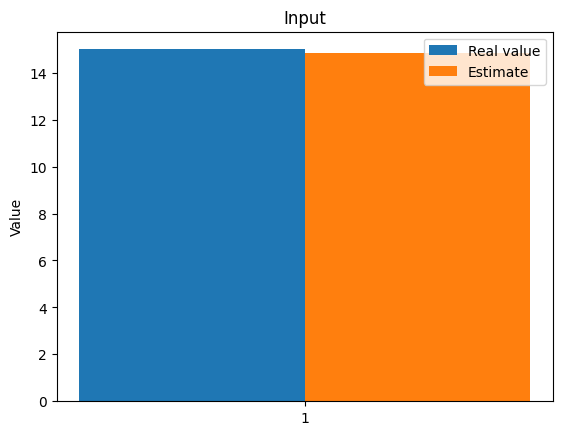

Sample 3000 / 3000

Average acceptance rate: 0.282 MCMC scale: 0.46465087216482126 

Mean values = [14.92725625]
Sample 2970 / 3000

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


Sample 3000 / 3000

Average acceptance rate: 0.3 MCMC scale: 0.46064245220908323 

Mean values = [14.9289876]
(2, 1, 1000)


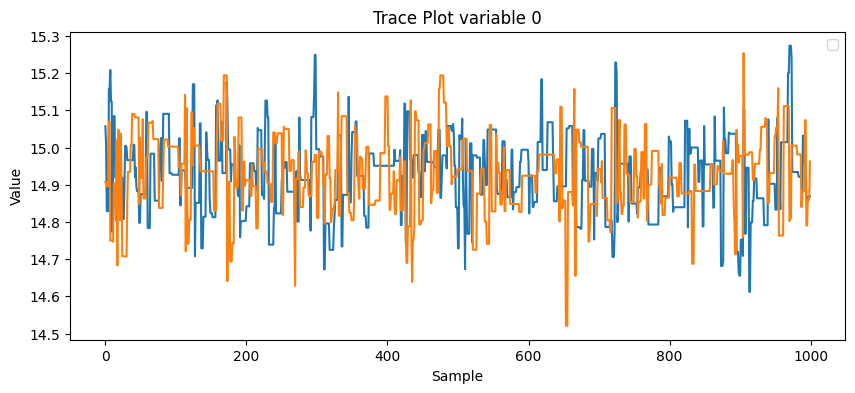

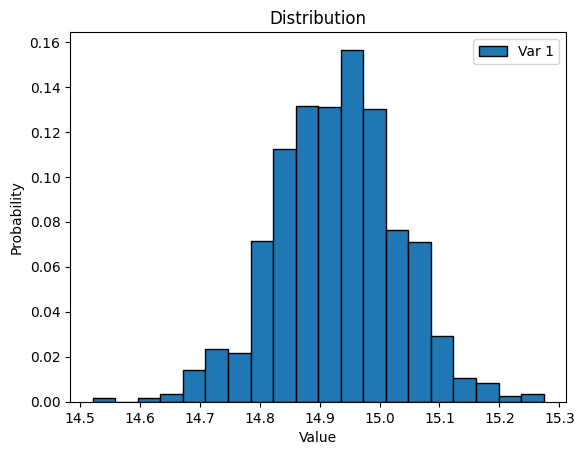

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


ESS values = 389.79802613337


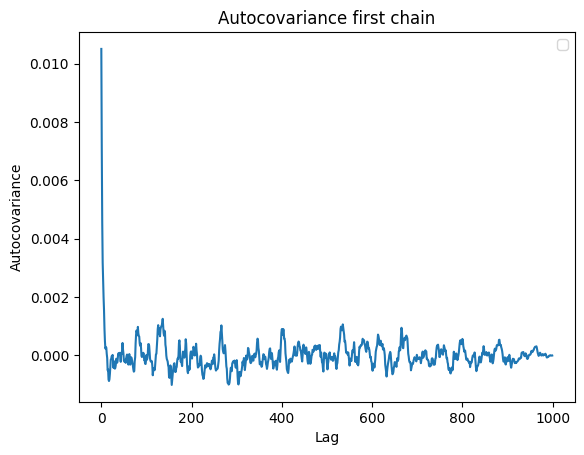

the difference between estimated values [0.0710124]



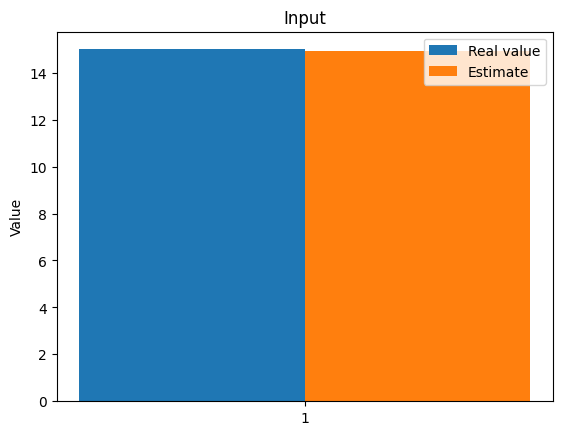

Sample 3000 / 3000

Average acceptance rate: 0.289 MCMC scale: 0.7922775411978211 

Mean values = [14.76791656]
Sample 2970 / 3000

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


Sample 3000 / 3000

Average acceptance rate: 0.337 MCMC scale: 0.7632909606658906 

Mean values = [14.75423846]
(2, 1, 1000)


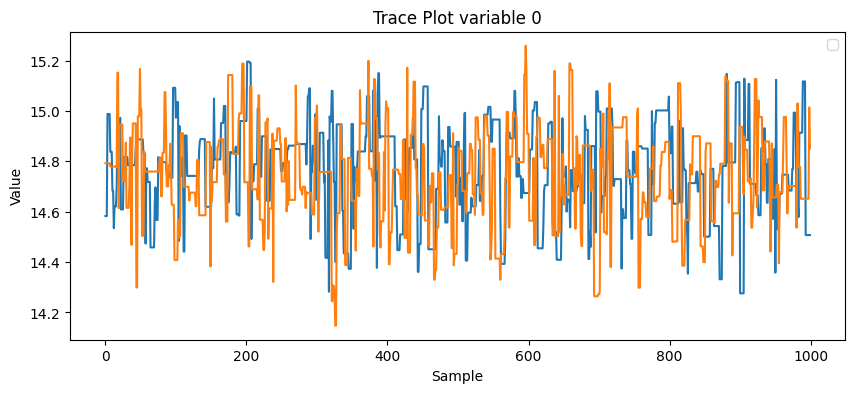

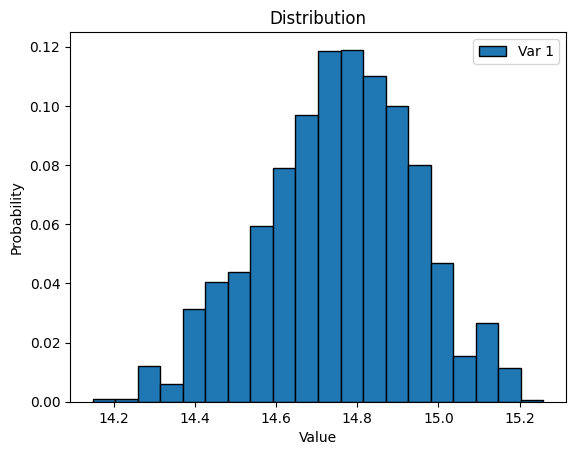

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


ESS values = 416.23731843630577


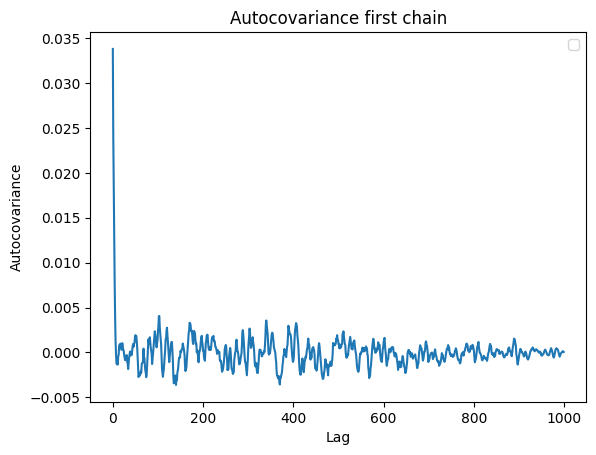

the difference between estimated values [0.24576154]



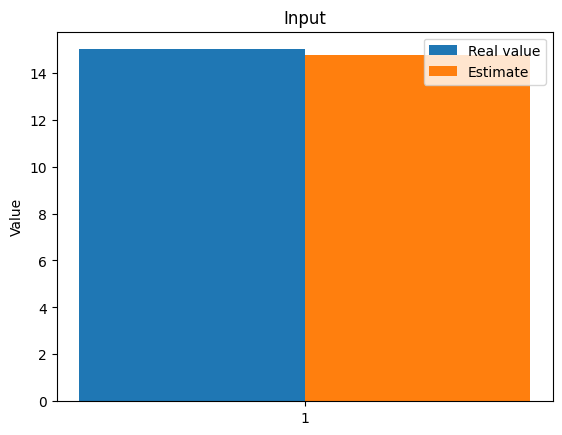

Sample 3000 / 3000

Average acceptance rate: 0.3 MCMC scale: 0.598474439023052 

Mean values = [14.88859857]
Sample 2970 / 3000

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


Sample 3000 / 3000

Average acceptance rate: 0.298 MCMC scale: 0.6395843175826605 

Mean values = [14.88477948]
(2, 1, 1000)


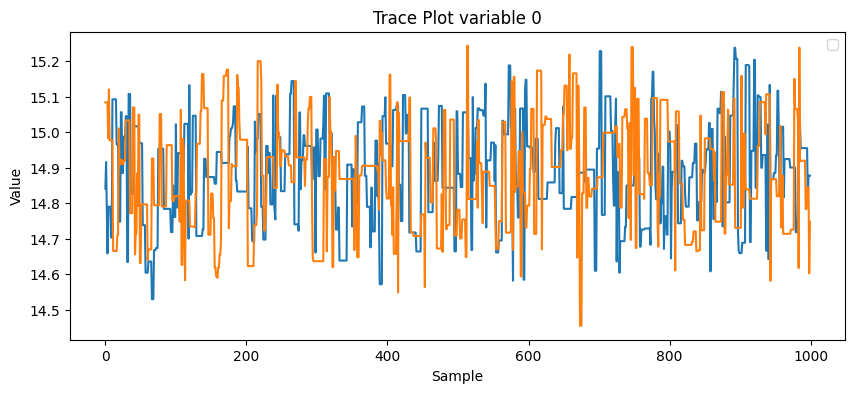

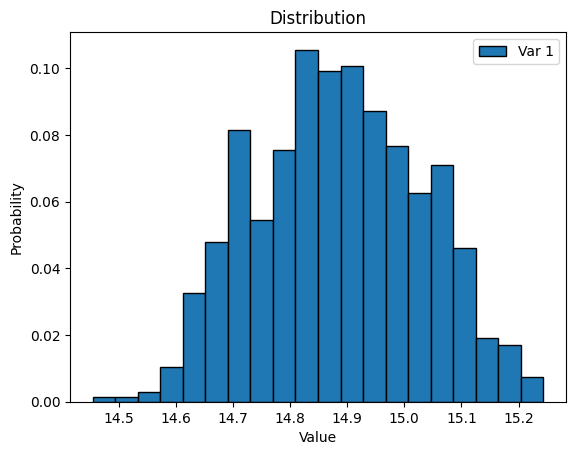

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


ESS values = 365.95467832527345


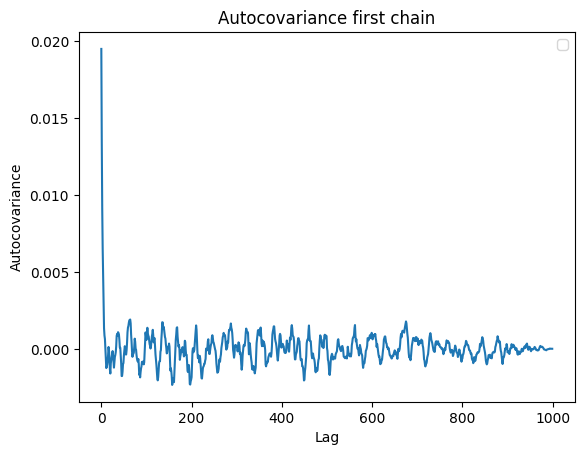

the difference between estimated values [0.11522052]



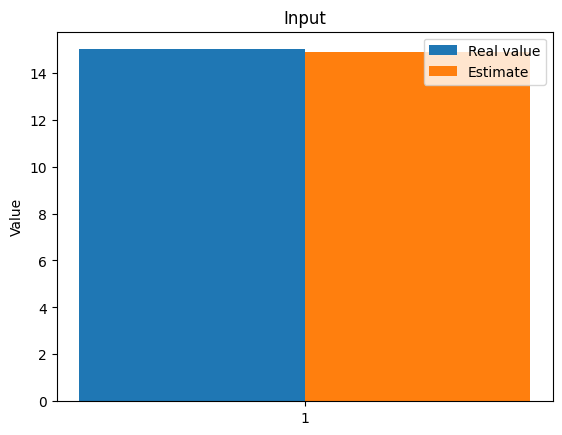

In [ ]:
# Define inputs
mean_prior = np.array([7.])
cov_prior = np.diag([1.])
Yhf = data["Yhf"]
sd_noise = [0.1,0.05]
N = 3000
burn_in = 2000
number_chains = 2
algo = "MH"
x_real = np.array([15.])
proposal_sd = [4.,2.]
adapt = True
n_data = [50,30]

x_data=  np.linspace(0., 5., n_data[0]).reshape(-1, 1)  # Generate evaluation times
nearest_x, y_obs = process_data(data["xhf"], x_real, x_data, Yhf) 

# estimates = final_model.inverse_cuqi(
#     mean_prior=mean_prior,
#     x_real=x_real,
#     y_obs=y_obs,
#     N=N,
#     burn_in=burn_in,
#     cov_prior=cov_prior,
#     sd_noise=sd_noise,  
#     adapt=adapt,
#     scale=proposal_sd,
#     proposal_sd=proposal_sd,
#     number_chains=number_chains,
#     algo=algo,
#     x_data=x_data
# )
estimates=run_simulation_cuqi(data,
    mean_prior,
    x_real,
    N,
    burn_in,
    cov_prior,
    sd_noise,  
    adapt,
    
    proposal_sd,
    number_chains,
    algo,
    x_data,
    n_data,
    final_model
) 


In [ ]:
    @compute_time
    def inverse_cuqi(self, mean_prior: np.ndarray, x_data: np.ndarray, cov_prior: Optional[np.ndarray] = None,
                      cov_noise: float = 0.1, cov_likelihood: Optional[np.ndarray] = None, y_obs: Optional[np.ndarray] = None, 
                      x_real: Optional[np.ndarray] = None, number_chains: int = 1, N: int = 1000, burn_in: int = 500, 
                      levels: int = 1, diagnostic: bool = True, rwmh_cov: Optional[np.ndarray] = None, rwmh_scaling: float = 0.1, 
                      rwmh_adaptive: bool = True, algo: str = "MH", transformation: List[Any] = []) -> Tuple[np.ndarray, np.ndarray]:

        self.transformations = transformation
        self.inputs = x_data

        if x_real is not None:
            dim = x_real.shape[0]
        elif y_obs is not None:
            dim = y_obs.shape[0]
        else:
            warnings.warn("No observation nor data given", UserWarning)
            return np.array([]), np.array([])

        if N <= burn_in:
            warnings.warn("Number of steps insufficient, smaller or equal to burn-in", UserWarning)

        if cov_prior is None:
            cov_prior = np.diag(mean_prior * 0.2)

        if cov_likelihood is None:
            cov_likelihood = cov_noise**2 * np.eye(dim)

        my_prior = multivariate_normal(mean=mean_prior, cov=cov_prior)

        if y_obs is None:
            y_obs = self.wrapper_prediction(x_real) + np.random.normal(loc=0., scale=cov_noise, size=x_real.shape)
        else:
            y_obs += np.random.normal(loc=0., scale=cov_noise, size=y_obs.shape)
            y_obs = y_obs.flatten()

        if levels > 1:
            if levels > len(self.model_list):
                warnings.warn("Number of levels is exceeding the number of models", UserWarning)
            else:
                my_loglike = [Gaussian(mean=y_obs, cov=cov_likelihood) for _ in range(levels)]
                my_posterior = [JointDistribution(my_prior, my_loglike[i])(self.model_list[i].wrapper_prediction) for i in range(levels)]
        else:
            my_loglike = Gaussian(mean=y_obs, cov=cov_likelihood)
            my_posterior = JointDistribution(my_prior, my_loglike)(self.wrapper_prediction)

        if rwmh_cov is None:
            rwmh_cov = np.eye(dim)

        estimates = self.MCMC_cuqi(my_posterior, N, burn_in, number_chains, diagnostic, rwmh_cov, rwmh_scaling, rwmh_adaptive, algo, dim)

        if diagnostic:
            self.plot_hist(estimates, x_real, self.wrapper_prediction(estimates), self.wrapper_prediction(x_real))
        
        error = np.abs(estimates - x_real) / np.abs(x_real + 1e-10)
        return estimates, error

    def MCMC_cuqi(self, posterior, N, burn_in, n=1, diagnostic=True, rwmh_cov=None, rwmh_scaling=0.1, rwmh_adaptive=True, algo="MH", dim=1):
        
        x_init = np.random.rand(dim, n)
        estimates = np.empty((dim, 0))
        chains = np.empty((0, dim, N - burn_in))
        post = np.empty((dim, 0))

        for i in range(n):
            if algo == "NUTS":
                sampler = NUTS(posterior, x0=x_init[:, i])
            elif algo == "MH":
                if rwmh_adaptive:
                    sampler = MH(posterior, x0=x_init[:, i], scale=rwmh_scaling)
                else:
                    sampler = MH(posterior, x0=x_init[:, i], scale=rwmh_scaling)
            elif algo == "pCN":
                sampler = pCN(posterior, x0=x_init[:, i])
            else:
                raise ValueError("Unknown algorithm %s" % algo)
            
            if rwmh_adaptive:
                samples = sampler.sample_adapt(N - burn_in, burn_in)
            else:
                samples = sampler.sample(N - burn_in, burn_in)

            estimates = np.column_stack((estimates, samples.mean()[:, np.newaxis]))
            chains = np.concatenate((chains, np.expand_dims(samples.samples, axis=0)), axis=0)
            post = np.concatenate((post, samples.samples), axis=1)

            print(f"Mean values = {estimates.mean(axis=1)}")

        print(chains.shape)
        for l in range(chains.shape[1]):
            plt.figure(figsize=(10, 4))
            for i in range(chains.shape[0]):
                plt.plot(chains[i, l, :])
            plt.xlabel('Sample')
            plt.ylabel('Value')
            plt.title(f'Trace Plot variable {l}')
            plt.legend()
            plt.show()
        
        if diagnostic:
            if n == 1:
                samples.plot_trace()
                samples.plot_autocorrelation()
            else:
                num_bins = 20
                plt.figure()
                for num in range(post.shape[0]):        
                    bin_edges = np.linspace(np.min(post[num, :]), np.max(post[num, :]), num_bins + 1)
                    hist, _ = np.histogram(post[num, :], bins=bin_edges)
                    hist = hist / post.shape[1]
                    bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
                    plt.bar(bin_centers, hist, width=np.diff(bin_edges), edgecolor='black', label=f'Var {num + 1}')
                    plt.xlabel('Value')
                    plt.ylabel('Probability')
                    plt.title('Distribution')
                    plt.legend()
                    plt.show()
                
                autocov = arviz.autocov(chains[:, 0, :])
                ess = arviz.ess(chains[:, 0, :])
                print(f"ESS values = {ess}")
                plt.figure()
                plt.plot(autocov[0, :])
                plt.title('Autocovariance first chain')
                plt.xlabel('Lag')
                plt.ylabel('Autocovariance')
                plt.legend()
                plt.show()
        
        return estimates